# 1. Install Dependencies and Setup

In [1]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for tensorflow-gpu
Failed to build tensorflow-gpu


  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [18 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\user\AppData\Local\Temp\pip-install-m_xug_4j\tensorflow-gpu_fcdc12aa18c444ccac950f9285906397\setup.py", line 37, in <module>
          raise Exception(TF_REMOVAL_WARNING)
      Exception:
      
      The "tensorflow-gpu" package has been removed!
      
      Please install "tensorflow" instead.
      
      Other than the name, the two packages have been identical
      since TensorFlow 2.1, or roughly since Sep 2019. For more
      information, see: pypi.org/project/tensorflow-gpu
      
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tensorflow-gpu
ERROR: Could not build

In [2]:
!pip list

Package                      Version
---------------------------- ------------
about-time                   4.2.1
absl-py                      2.1.0
aiofiles                     23.2.1
aiohttp                      3.8.5
aiosignal                    1.3.1
alive-progress               3.1.4
annotated-types              0.5.0
anyio                        3.7.1
asttokens                    2.4.0
astunparse                   1.6.3
async-timeout                4.0.3
attrs                        23.1.0
backcall                     0.2.0
backoff                      2.2.1
bcrypt                       4.0.1
beautifulsoup4               4.12.2
Brotli                       1.1.0
cachetools                   5.3.2
certifi                      2023.7.22
cffi                         1.15.1
charset-normalizer           3.2.0
chroma-hnswlib               0.7.3
chromadb                     0.4.13
ci-info                      0.3.0
click                        8.1.7
colorama                     0.4.6
co


[notice] A new release of pip is available: 23.3.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
import os

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
tf.config.list_physical_devices('GPU')

[]

# 2. Remove dodgy images

In [4]:
import cv2
import imghdr

C:\Users\user\AppData\Local\Temp\ipykernel_10592\4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
data_dir = 'dataa' 

In [6]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [7]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# 3. Load Data

In [8]:
import numpy as np
from matplotlib import pyplot as plt

In [9]:
data = tf.keras.utils.image_dataset_from_directory('dataa')

Found 1840 files belonging to 2 classes.


In [10]:
data_iterator = data.as_numpy_iterator()

In [11]:
batch = data_iterator.next()

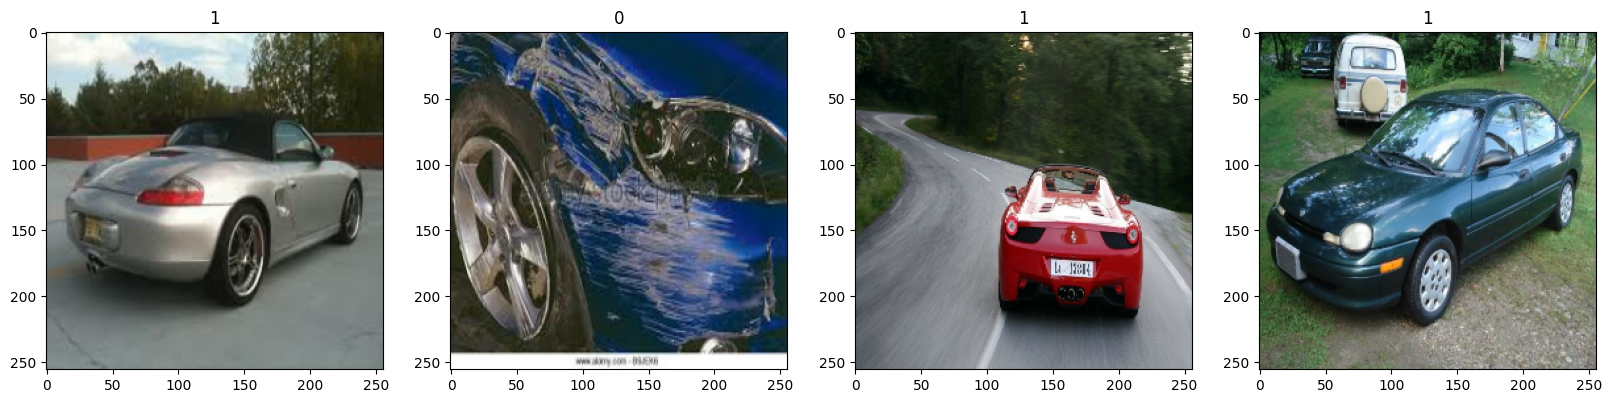

In [12]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [13]:
data = data.map(lambda x,y: (x/255, y))

In [14]:
data.as_numpy_iterator().next()

(array([[[[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         ...,
 
         [[1.        , 1.        , 1.        ],
          [1.     

# 5. Split Data

In [15]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [16]:
train_size

40

In [17]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 6. Build Deep Learning Model

In [18]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [20]:
model = Sequential()

In [21]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [22]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 16)        4624      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 16)        0

# 7. Train

In [24]:
logdir='logs'

In [25]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [26]:
hist = model.fit(train, epochs=10, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/10


40/40 [==============================] - 30s 689ms/step - loss: 0.7524 - accuracy: 0.5844 - val_loss: 0.6462 - val_accuracy: 0.6392
Epoch 2/10
40/40 [==============================] - 26s 633ms/step - loss: 0.5401 - accuracy: 0.7180 - val_loss: 0.4476 - val_accuracy: 0.7955
Epoch 3/10
40/40 [==============================] - 26s 626ms/step - loss: 0.4513 - accuracy: 0.8047 - val_loss: 0.3887 - val_accuracy: 0.8267
Epoch 4/10
40/40 [==============================] - 24s 580ms/step - loss: 0.3623 - accuracy: 0.8484 - val_loss: 0.4056 - val_accuracy: 0.8466
Epoch 5/10
40/40 [==============================] - 24s 591ms/step - loss: 0.3116 - accuracy: 0.8844 - val_loss: 0.4046 - val_accuracy: 0.8352
Epoch 6/10
40/40 [==============================] - 24s 581ms/step - loss: 0.2121 - accuracy: 0.9266 - val_loss: 0.3091 - val_accuracy: 0.8636
Epoch 7/10
40/40 [==============================] - 24s 585ms/step - loss: 0.1495 - accuracy: 0.9453 - val_loss: 0.4326 - val_accuracy: 0.83

# 8. Plot Performance

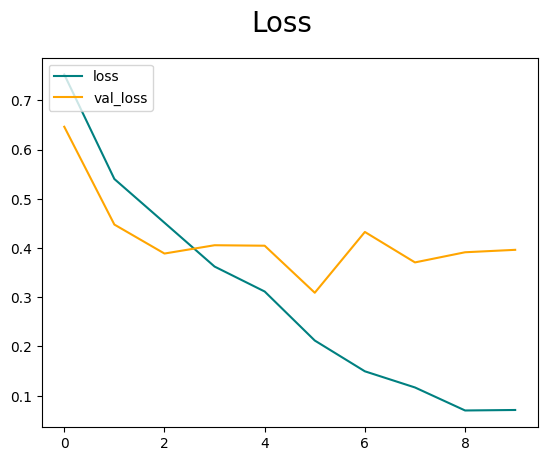

In [27]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

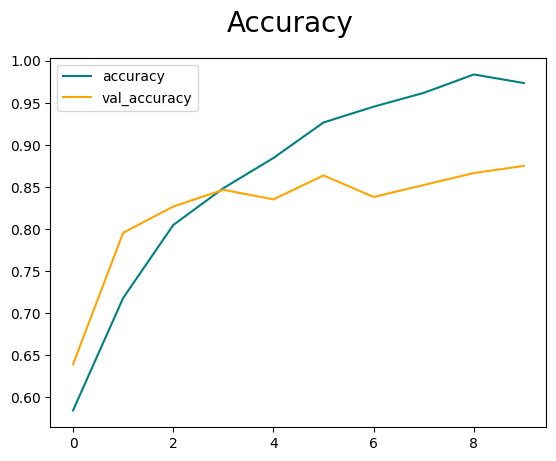

In [28]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# 9. Evaluate

In [29]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [30]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [31]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 [==============================] - 0s 122ms/step


In [32]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.90909094, shape=(), dtype=float32) tf.Tensor(0.8045977, shape=(), dtype=float32) tf.Tensor(0.85, shape=(), dtype=float32)


# 10. Test

In [33]:
import cv2

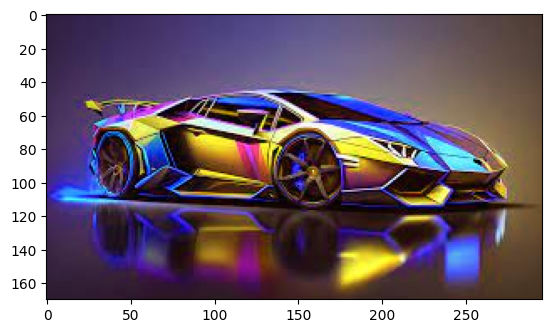

In [34]:
img = cv2.imread('notdamaged.jpg')
plt.imshow(img)
plt.show()

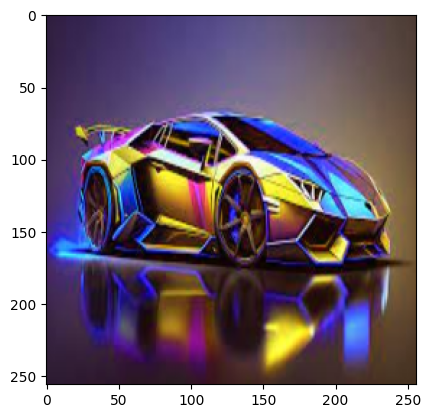

In [35]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [36]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 90ms/step


In [37]:
yhat

array([[0.9952241]], dtype=float32)

In [38]:
if yhat > 0.5: 
    print(f'Car is not damaged')
else:
    print(f'Car is damaged')

Car is not damaged


<h1>Generate Shares and Save the Image <h1>

In [6]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageDraw, ImageFont, ImageTk
from tensorflow.keras.models import load_model
import os

# Détection des dommages sur une voiture
def detect_damage(image, model):
    """Détecte si une voiture est endommagée ou non."""
    resize = cv2.resize(image, (256, 256))  # Le modèle attend un input 256x256
    yhat = model.predict(np.expand_dims(resize / 255.0, 0))[0][0]
    damaged = yhat <= 0.5
    return damaged

# Ajout de texte sur une image
def add_text_to_image(image, text):
    """Ajoute un texte visible à une image."""
    pil_img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil_img)
    width, height = pil_img.size

    try:
        font = ImageFont.truetype("arial.ttf", 35)
    except IOError:
        font = ImageFont.load_default()

    # Positionner le texte en haut de l'image
    text_bbox = draw.textbbox((0, 0), text, font=font)
    text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
    text_position = ((width - text_width) // 2, 20)  # Placer le texte en haut (20 pixels de marge)
    draw.text(text_position, text, fill=(255, 0, 0), font=font)

    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


# Génération des partages
def generate_n_shares(image, n, output_folder):
    """Génère n partages à partir d'une image et les sauvegarde dans un dossier."""
    rows, cols, _ = image.shape
    shares = [np.random.randint(0, 256, (rows, cols, 3), dtype=np.uint8) for _ in range(n - 1)]
    last_share = image.copy()
    for share in shares:
        last_share = cv2.bitwise_xor(last_share, share)
    shares.append(last_share)

    # Enregistrer les partages et l'image dans le dossier
    os.makedirs(output_folder, exist_ok=True)
    for i, share in enumerate(shares):
        share_path = os.path.join(output_folder, f"share_{i + 1}.png")
        cv2.imwrite(share_path, share)
    
    # Save the original image with predicted result
    original_image_with_text_path = os.path.join(output_folder, "original_image_with_prediction.png")
    cv2.imwrite(original_image_with_text_path, image)

    return shares, original_image_with_text_path


# Conversion d'une image OpenCV en image Tkinter
def cv_to_tk(cv_image, max_size=400):
    """Convertit une image OpenCV en image compatible Tkinter."""
    height, width = cv_image.shape[:2]
    if max(height, width) > max_size:
        scale = max_size / max(height, width)
        cv_image = cv2.resize(cv_image, (int(width * scale), int(height * scale)))

    color_coverted = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(color_coverted)
    tk_img = ImageTk.PhotoImage(pil_img)
    return tk_img


# Sélection d'une image
def open_image_for_shares():
    filepath = filedialog.askopenfilename(title="Select an Image", filetypes=[("Image Files", ".jpg;.png;*.jpeg")])
    if filepath:
        entry_image_for_shares.delete(0, tk.END)
        entry_image_for_shares.insert(0, filepath)


# Fonction pour vérifier et obtenir le prochain numéro de dossier disponible
def get_next_folder_number(base_folder):
    """Trouve le prochain numéro de dossier disponible (ex: '001', '002', etc.)."""
    i = 1
    while True:
        folder_name = f"{base_folder}{i:03d}"  # Format '001', '002', ...
        if not os.path.exists(folder_name):
            return folder_name
        i += 1


# Traitement de l'image et génération des partages
def process_shares():
    image_path = entry_image_for_shares.get()
    try:
        n_shares = int(entry_shares.get())
    except ValueError:
        messagebox.showerror("Input Error", "Please enter a valid number of shares.")
        return

    if not image_path:
        messagebox.showerror("Input Error", "Please select an image.")
        return

    # Charger l'image
    img = cv2.imread(image_path)

    # Charger le modèle
    model = load_model("models/imageclassifier.h5")  # Ajustez le chemin au besoin

    # Détection des dommages et génération du texte
    is_damaged = detect_damage(img, model)
    text = "This car is damaged" if is_damaged else "This car is not damaged"

    # Ajouter du texte sur l'image originale
    image_with_text = add_text_to_image(img, text)

    # Obtenir le prochain numéro de dossier disponible
    output_folder = get_next_folder_number("folder_")
    
    # Générer les partages
    shares, original_image_with_text_path = generate_n_shares(image_with_text, n_shares, output_folder)

    # Afficher un message de confirmation
    messagebox.showinfo("Success", f"Shares have been saved in {output_folder}\nOriginal image with prediction saved as {original_image_with_text_path}")


# Interface principale pour générer des partages
root = tk.Tk()
root.title("Generate Shares")

# Ajout d'une icône à la fenêtre (remplacez "icon.ico" par votre fichier d'icône)
try:
    root.iconbitmap("icon.ico")
except:
    pass  # Ignore si l'icône est introuvable

# Configuration des styles et couleurs
root.configure(bg="#2b2b2b")  # Fond gris foncé
button_style = {"bg": "#4CAF50", "fg": "white", "activebackground": "#45a049", "activeforeground": "white", "font": ("Arial", 12, "bold")}
label_style = {"bg": "#2b2b2b", "fg": "white", "font": ("Arial", 12)}
entry_style = {"bg": "#3c3f41", "fg": "white", "insertbackground": "white", "font": ("Arial", 12)}

# Widgets pour sélectionner l'image
tk.Label(root, text="Select an Image for Shares:", **label_style).pack(pady=10)
entry_image_for_shares = tk.Entry(root, width=50, **entry_style)
entry_image_for_shares.pack(pady=5)
tk.Button(root, text="Browse", command=open_image_for_shares, **button_style).pack(pady=5)

# Entrée pour le nombre de partages
tk.Label(root, text="Enter Number of Shares:", **label_style).pack(pady=10)
entry_shares = tk.Entry(root, width=10, **entry_style)
entry_shares.pack(pady=5)

# Bouton pour générer les partages
tk.Button(root, text="Generate Shares", command=process_shares, **button_style).pack(pady=20)

# Ajout d'un cadre pour une meilleure esthétique
frame = tk.Frame(root, bg="#2b2b2b", bd=5)
frame.pack(fill="both", expand=True, padx=10, pady=10)

# Lancement de la fenêtre principale
root.mainloop()

1/1 [==============================] - 0s 121ms/step


<h1> Reconstruct Image from Sahres <h1>

In [1]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageDraw, ImageFont, ImageTk
import os
from tensorflow.keras.models import load_model


# Reconstruction de l'image
def reconstruct_image(shares):
    """Reconstruit l'image à partir des partages."""
    reconstructed = shares[0]
    for share in shares[1:]:
        reconstructed = cv2.bitwise_xor(reconstructed, share)
    return reconstructed


# Ajout de texte sur une image
def add_text_to_image(image, text):
    """Ajoute un texte visible à une image."""
    pil_img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil_img)
    width, height = pil_img.size

    try:
        font = ImageFont.truetype("arial.ttf", 35)
    except IOError:
        font = ImageFont.load_default()

    # Positionner le texte en haut de l'image
    text_bbox = draw.textbbox((0, 0), text, font=font)
    text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
    text_position = ((width - text_width) // 2, 20)  # Placer le texte en haut (20 pixels de marge)
    draw.text(text_position, text, fill=(255, 0, 0), font=font)

    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


# Conversion d'une image OpenCV en image Tkinter
def cv_to_tk(cv_image, max_size=400):
    """Convertit une image OpenCV en image compatible Tkinter."""
    height, width = cv_image.shape[:2]
    if max(height, width) > max_size:
        scale = max_size / max(height, width)
        cv_image = cv2.resize(cv_image, (int(width * scale), int(height * scale)))

    color_coverted = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(color_coverted)
    tk_img = ImageTk.PhotoImage(pil_img)
    return tk_img


# Sélectionner les partages pour reconstruction
def open_shares_for_reconstruction(entry_shares_for_reconstruction):
    # Sélectionner plusieurs fichiers partages
    share_files = filedialog.askopenfilenames(title="Select Share Images", filetypes=[("PNG Files", "*.png")])
    if share_files:
        entry_shares_for_reconstruction.delete(0, tk.END)
        entry_shares_for_reconstruction.insert(0, ', '.join(share_files))  # Afficher les fichiers sélectionnés


# Traitement des partages pour reconstruction
def process_reconstruction(entry_shares_for_reconstruction, panel_reconstructed):
    share_files = entry_shares_for_reconstruction.get().split(', ')
    if not share_files:
        messagebox.showerror("Input Error", "Please select the share images.")
        return

    try:
        # Charger les fichiers des partages
        shares = [cv2.imread(file) for file in share_files]
    except Exception as e:
        messagebox.showerror("Error", f"Failed to load shares: {e}")
        return

    # Reconstruct the image
    reconstructed_image = reconstruct_image(shares)

    # Charger le modèle
    model = load_model("models/imageclassifier.h5")  # Ajustez le chemin au besoin

    # Prediction and damage detection
    text = "This car is damaged" if detect_damage(reconstructed_image, model) else "This car is not damaged"

    # Ajouter du texte sur l'image reconstruite
    reconstructed_with_text = add_text_to_image(reconstructed_image, text)

    # Convertir l'image reconstruite en format Tkinter et l'afficher
    reconstructed_tk = cv_to_tk(reconstructed_with_text)
    panel_reconstructed.configure(image=reconstructed_tk)
    panel_reconstructed.image = reconstructed_tk


# Interface pour la reconstruction
# Interface pour la reconstruction
def reconstruction_window():
    window = tk.Tk()
    window.title("Reconstruct Image from Shares")

    # Ajout d'une icône à la fenêtre (remplacez "icon.ico" par votre fichier d'icône)
    try:
        window.iconbitmap("icon.ico")
    except:
        pass  # Ignore si l'icône est introuvable

    # Configuration des styles et couleurs
    window.configure(bg="#2b2b2b")  # Fond gris foncé
    button_style = {"bg": "#4CAF50", "fg": "white", "activebackground": "#45a049", "activeforeground": "white", "font": ("Arial", 12, "bold")}
    label_style = {"bg": "#2b2b2b", "fg": "white", "font": ("Arial", 12)}
    entry_style = {"bg": "#3c3f41", "fg": "white", "insertbackground": "white", "font": ("Arial", 12)}

    # Sélectionner les partages
    tk.Label(window, text="Select Share Images:", **label_style).pack(pady=10)
    entry_shares_for_reconstruction = tk.Entry(window, width=50, **entry_style)
    entry_shares_for_reconstruction.pack(pady=5)
    tk.Button(window, text="Browse", command=lambda: open_shares_for_reconstruction(entry_shares_for_reconstruction), **button_style).pack(pady=5)

    # Bouton pour reconstruire l'image et afficher la prédiction
    tk.Button(window, text="Reconstruct Image", command=lambda: process_reconstruction(entry_shares_for_reconstruction, panel_reconstructed), **button_style).pack(pady=20)

    # Afficher l'image reconstruite
    tk.Label(window, text="Reconstructed Image with Prediction", **label_style).pack(pady=10)
    panel_reconstructed = tk.Label(window, bg="#2b2b2b")
    panel_reconstructed.pack(pady=10)

    # Ajout d'un cadre pour une meilleure organisation visuelle
    frame = tk.Frame(window, bg="#2b2b2b", bd=5)
    frame.pack(fill="both", expand=True, padx=10, pady=10)

    window.mainloop()

# Run the reconstruction window
reconstruction_window()

# 11. Save the Model

In [2]:
from keras.models import load_model


In [5]:
new_model = load_model('models/imageclassifier.h5')

In [50]:
new_image = cv2.imread('test.jpg')

In [51]:
new_model.predict(np.expand_dims(tf.image.resize(new_image, (256,256))/255, 0))

1/1 [==============================] - 0s 31ms/step


array([[0.04402399]], dtype=float32)